Epoch 1/5


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7813 - loss: 0.7625 - val_accuracy: 0.9194 - val_loss: 0.2628
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9421 - loss: 0.1948 - val_accuracy: 0.9350 - val_loss: 0.1952
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9593 - loss: 0.1384 - val_accuracy: 0.9469 - val_loss: 0.1883
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.0882 - val_accuracy: 0.9419 - val_loss: 0.1821
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0697 - val_accuracy: 0.9531 - val_loss: 0.1627
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       398
           1       0.95      0.99      0.97       439
           2       0.93      0.98      0.96       363
           3       0.98      0.92      0.95       395
           4       0.95      0.95      0.95       390
         

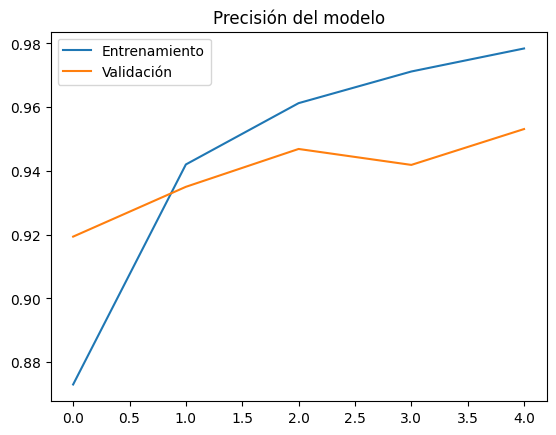

In [ ]:
from Model import create_model
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import numpy as np


datos = np.load("datos_privados/usuario_1.npz")  # Cambia el número según tu equipo
x_train = datos["x"]
y_train = datos["y"]

# Separar parte para test local si quieres evaluar
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


model = create_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

np.savez("pesos_usuario.npz", *model.get_weights())

# Evaluar con classification report
y_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred))

# Curvas de aprendizaje
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title("Precisión del modelo")
plt.legend()
plt.show()
